## <center> Prelims 2024
### <center> Mani Tyagi
#### <center> 200973108

In [21]:
# importing libraries
import matplotlib.pyplot as plt
import numpy as np
from numpy.polynomial import legendre as leg
from numpy.polynomial import hermite as herm
import random
import time

### Part (a)

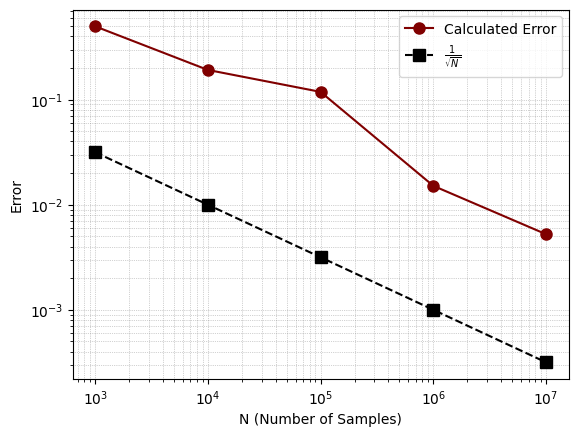

In [22]:
# Provided data form c++ code
N = [1000, 10000, 100000, 1000000, 10000000]
errors = [0.499259, 0.191941, 0.118619, 0.0151308, 0.00524277]

# Calculate theoretical error for comparison (1/sqrt(N))
theoretical_errors = [1 / np.sqrt(n) for n in N]


# Plot the error vs N
plt.loglog(N, errors, 'o-', label='Calculated Error',color='maroon', markersize=8)
plt.loglog(N, theoretical_errors, 's--', color='black', label=r'$\frac{1}{\sqrt{N}}$', markersize=8)

# Add titles and labels
plt.xlabel('N (Number of Samples)')
plt.ylabel('Error')
plt.legend()
plt.minorticks_on()
plt.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray', alpha=0.7)

# Show the plot
plt.show()

In [29]:
def calculate_volume(a, b, c, num_samples):
    count = 0
    start_time = time.time()
    
    for _ in range(num_samples):
        x = random.uniform(-a, a)
        y = random.uniform(-b, b)
        z = random.uniform(-c, c)
        
        if (x**2)/(a**2) + (y**2)/(b**2) + (z**2)/(c**2) < 1:
            count += 1
    
    duration = time.time() - start_time
    volume = 8 * a * b * c * (count / num_samples)
    
    return volume, duration

def main():
    a = 3.0
    b = 2.0
    c = 1.0
    V_exact = (4.0 / 3.0) * np.pi * a * b * c
    n_values = [1000, 10000, 100000, 1000000, 10000000]
    
    print("-" * 77)
    print(f"{'N':<12} {'Calculated Volume':<20} {'Error':<25} {'Duration (s)':<15}")
    print("-" * 77)
    
    for N in n_values:
        volume, duration = calculate_volume(a, b, c, N)
        error = abs(V_exact - volume)
        print(f"{N:<12} {volume:<20} {error:<25} {duration:<15}")
    
    print("-" * 77)

if __name__ == "__main__":
    main()


-----------------------------------------------------------------------------
N            Calculated Volume    Error                     Duration (s)   
-----------------------------------------------------------------------------
1000         24.048000000000002   1.084741228718343         0.0011456012725830078
10000        25.0656              0.06714122871834505       0.011156320571899414
100000       25.20816             0.07541877128165453       0.12026047706604004
1000000      25.124016            0.008725228718343914      1.1707217693328857
10000000     25.1394384           0.00669717128165459       10.811669111251831
-----------------------------------------------------------------------------


### Part (b)

To transform the integral domain from [-5,0] to [-1,1], we can use
$$ 
\int_a^b f(x)dx = \dfrac{b-a}{2}\sum_{i=0}^{n} w_i f(\dfrac{b-a}{2}x_i + \dfrac{b+a}{2})
$$

In [25]:
# defining the function to be integrated
def f(x): 
    return x**2 + 1

# defining function to perform Gauss legendre quadrature
def Gauss_legendre(n, a, b):
    sum = 0.0
    xi, wi = leg.leggauss(n)
    
    for i in range(n):
        sum = sum + wi[i] * f(((b-a)/2)*xi[i] + (b+a)/2)
    
    return ((b - a) / 2.0) * sum

In [26]:
# Define the integration limits
a = -5
b = 0

# List of different values of n
n_values = [1, 2, 3, 4, 5]

# Calculate the integral for different values of n
results = []
for n in n_values:
    integral = Gauss_legendre(n, a, b)
    results.append(integral)

# Exact value of the integral for comparison
exact_value = 46.6667
exact_value = exact_value

# Calculate errors and convergence rates
errors = [abs(result - exact_value) for result in results]

# Print the results in a formatted table
print("-" * 60)
print(f"{'n':<10} {'Calculated Integral':<25} {'Error':<25}")
print("-" * 60)
for i in range(len(n_values)):
    if i == 0:
        print(f"{n_values[i]:<10} {results[i]:<25} {errors[i]:<25}")
    else:
        print(f"{n_values[i]:<10} {results[i]:<25} {errors[i]:<25}")
print("-" * 60)

------------------------------------------------------------
n          Calculated Integral       Error                    
------------------------------------------------------------
1          36.25                     10.416699999999999       
2          46.66666666666666         3.333333334154531e-05    
3          46.66666666666666         3.333333334154531e-05    
4          46.66666666666666         3.333333334154531e-05    
5          46.66666666666668         3.333333332022903e-05    
------------------------------------------------------------


### Part (c)

In [27]:
# Define the function to be integrated
def integrand(u):
    return (u**2 + 2*u + 5)/(8.0)

# Number of Gauss-Hermite nodes
n_values = [1, 2, 3, 4, 5, 6]
I_exact = 1.218562022497542

# Calculate the integral for different values of n
results = []
errors = []
for n in n_values:
    nodes, weights = herm.hermgauss(n)
    integral = np.sum(weights * integrand(nodes))
    results.append(integral)
    errors.append(np.abs(integral - I_exact))

# Print the results in a formatted table
print("-" * 60)
print(f"{'n':<10} {'Calculated Integral':<25} {'Error':<25}")
print("-" * 60)
for i in range(len(n_values)):
    print(f"{n_values[i]:<10} {results[i]:<25} {errors[i]:<25}")
print("-" * 60)

------------------------------------------------------------
n          Calculated Integral       Error                    
------------------------------------------------------------
1          1.1077836568159474        0.1107783656815946       
2          1.2185620224975422        2.220446049250313e-16    
3          1.2185620224975422        2.220446049250313e-16    
4          1.2185620224975422        2.220446049250313e-16    
5          1.218562022497542         0.0                      
6          1.218562022497542         0.0                      
------------------------------------------------------------
